In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
plt.style.use('ggplot')

In [3]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.select_dtypes(include='object').columns:
    blanks=(df[col].str.strip()=='').sum()
    print(f'{col}:{blanks}')

customerID:0
gender:0
Partner:0
Dependents:0
PhoneService:0
MultipleLines:0
InternetService:0
OnlineSecurity:0
OnlineBackup:0
DeviceProtection:0
TechSupport:0
StreamingTV:0
StreamingMovies:0
Contract:0
PaperlessBilling:0
PaymentMethod:0
TotalCharges:11
Churn:0


In [11]:
df[df['TotalCharges'].str.strip()=='']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges']=df['TotalCharges'].replace(r'^\s*$',np.nan,regex=True)

In [19]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [20]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
df.dropna(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.drop('customerID',axis=1,inplace=True)

In [25]:
df.duplicated().sum()

np.int64(22)

In [26]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

EDA

Text(0, 0.5, 'Number of Customers ')

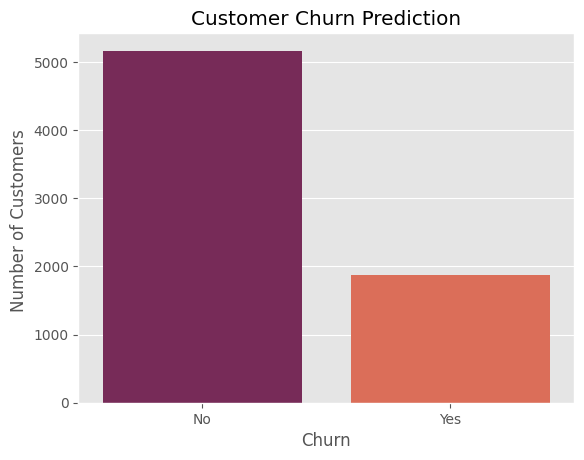

In [27]:
sns.countplot(x=df['Churn'],palette='rocket')
plt.title('Customer Churn Prediction')
plt.xlabel('Churn')
plt.ylabel('Number of Customers ')

Observation
-Most customers did not churn.
-Around one-quarter of customers churned.
-The dataset is moderately imbalanced.
Business Insight
-Although most customers stay, a significant proportion leave the company.
-Since the classes are not perfectly balanced, relying only on accuracy may be
-misleading. Metrics such as Precision, Recall, F1-score, and ROC-AUC will also be        considered during model evaluation.

In [35]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include='object').columns
print(f'numerical columns are--{num_cols}')
print(f'categorical columns are--{cat_cols}')

numerical columns are--Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
categorical columns are--Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


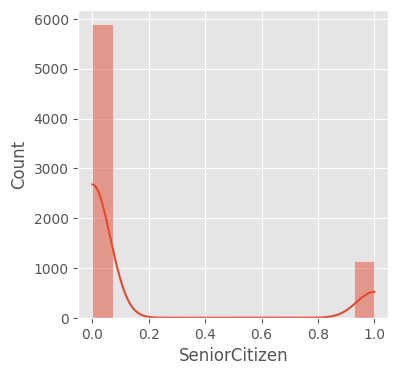

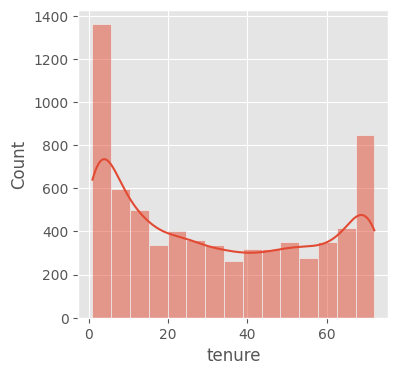

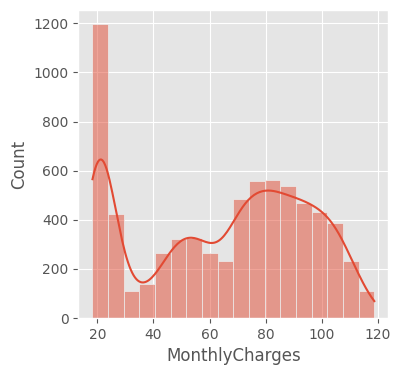

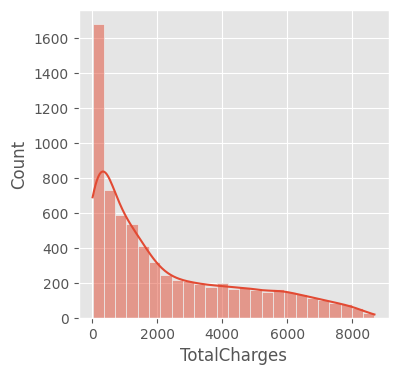

In [38]:
for  col in num_cols:
    plt.figure(figsize=(4,4))
    sns.histplot(x=df[col],kde=True)

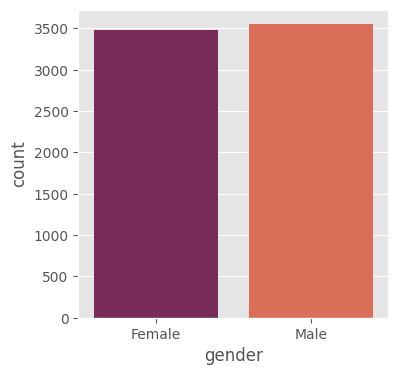

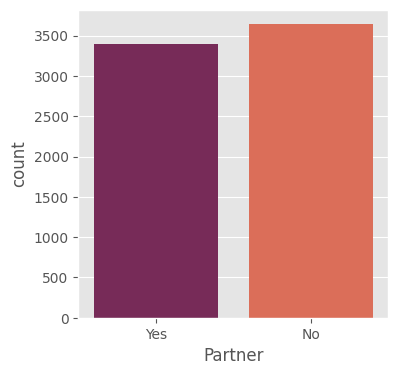

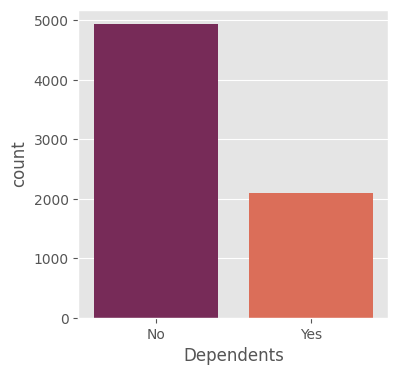

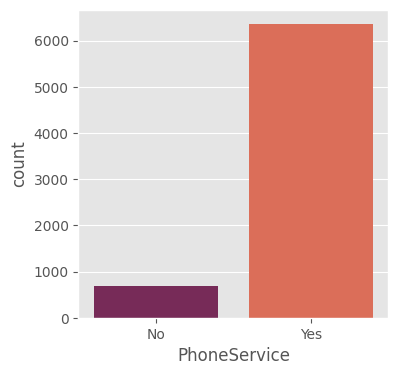

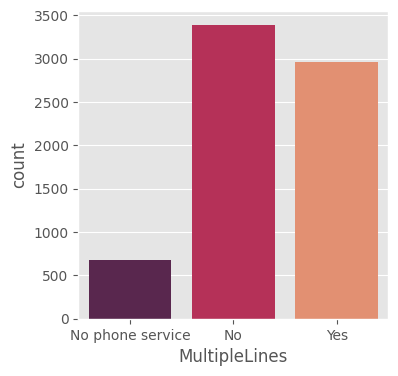

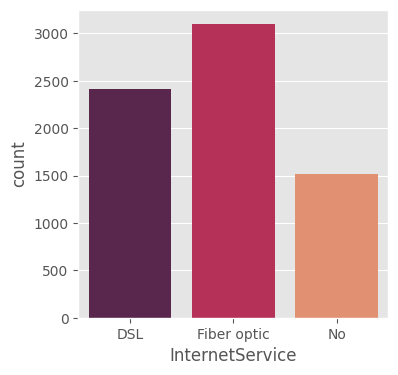

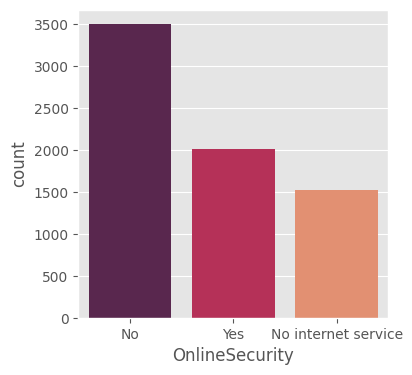

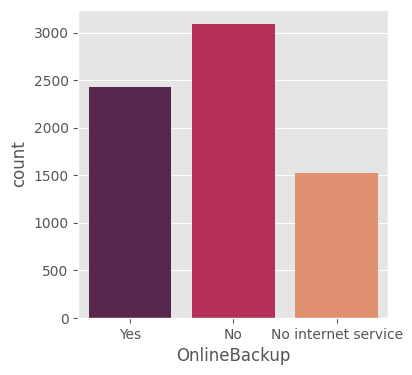

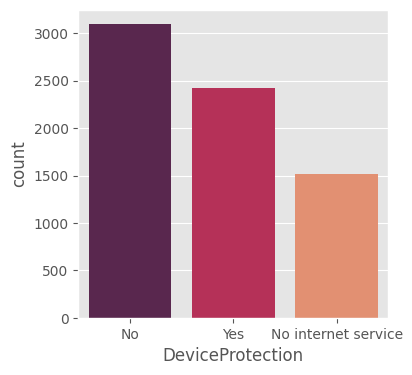

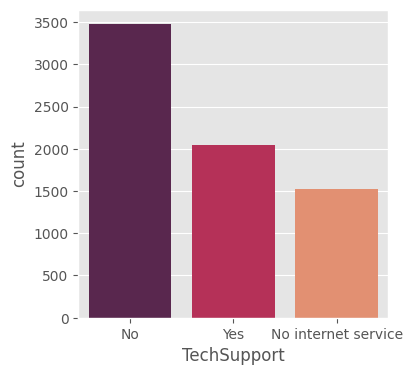

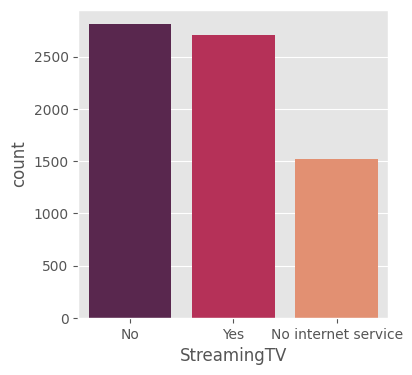

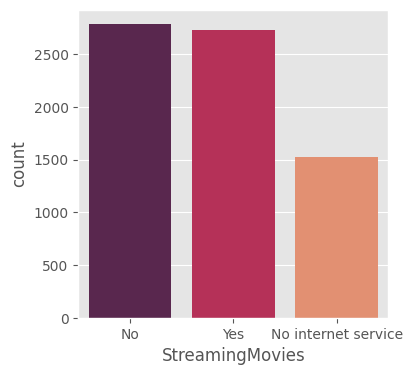

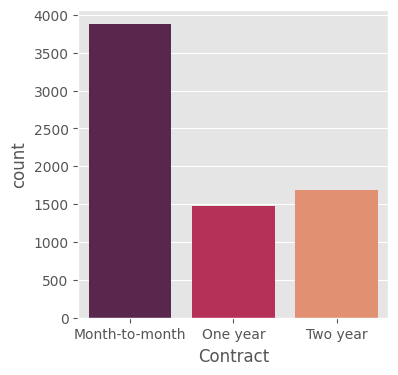

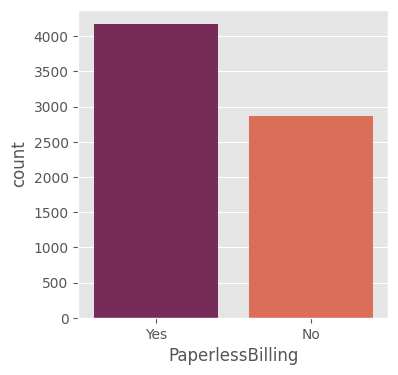

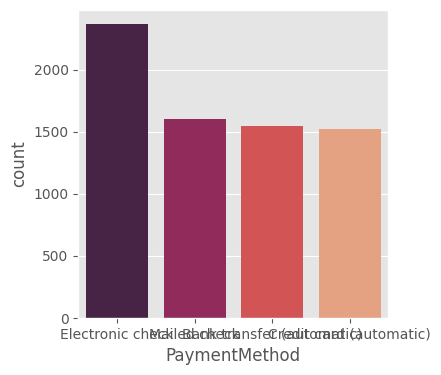

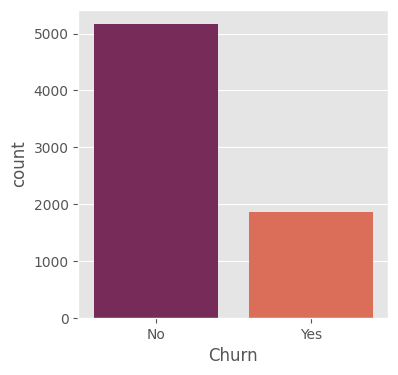

In [41]:
for col in cat_cols:
    plt.figure(figsize=(4,4))
    sns.countplot(x=df[col],palette='rocket')

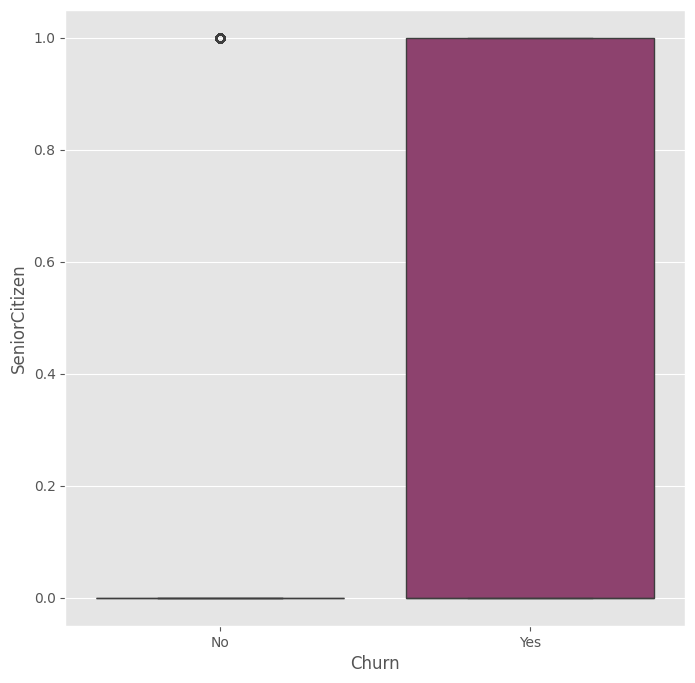

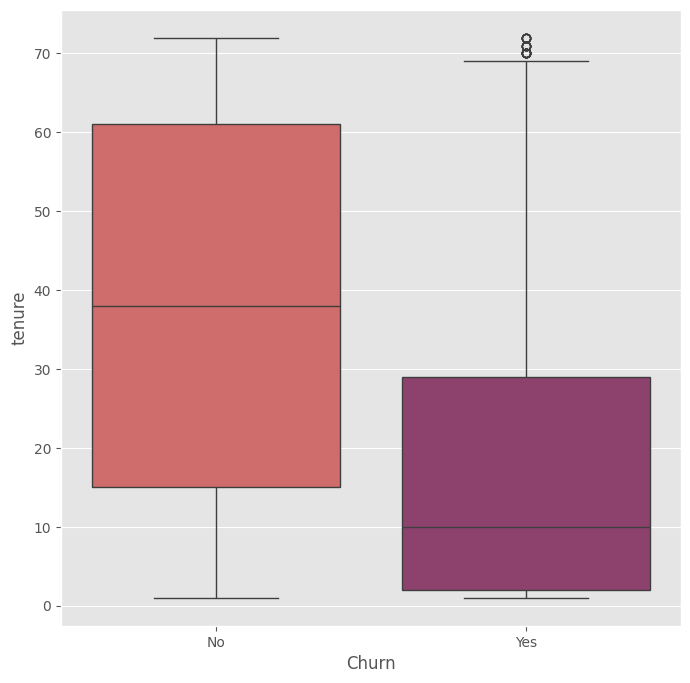

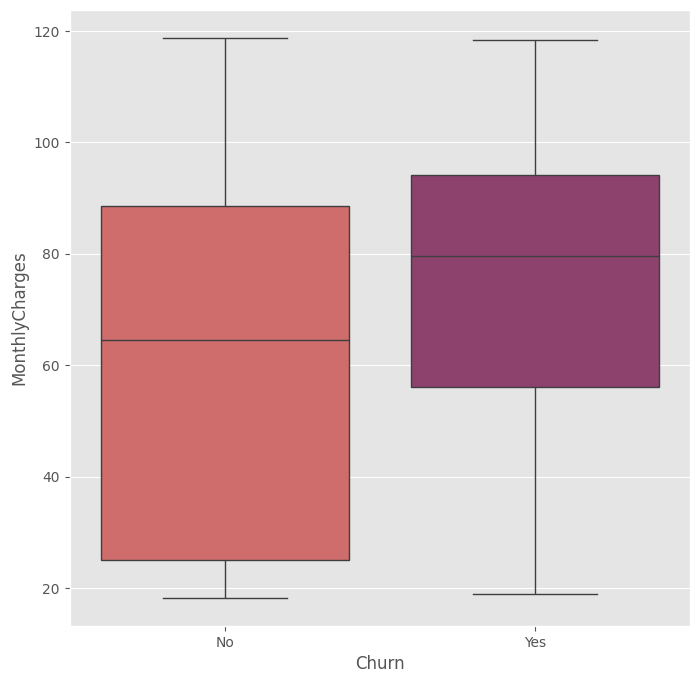

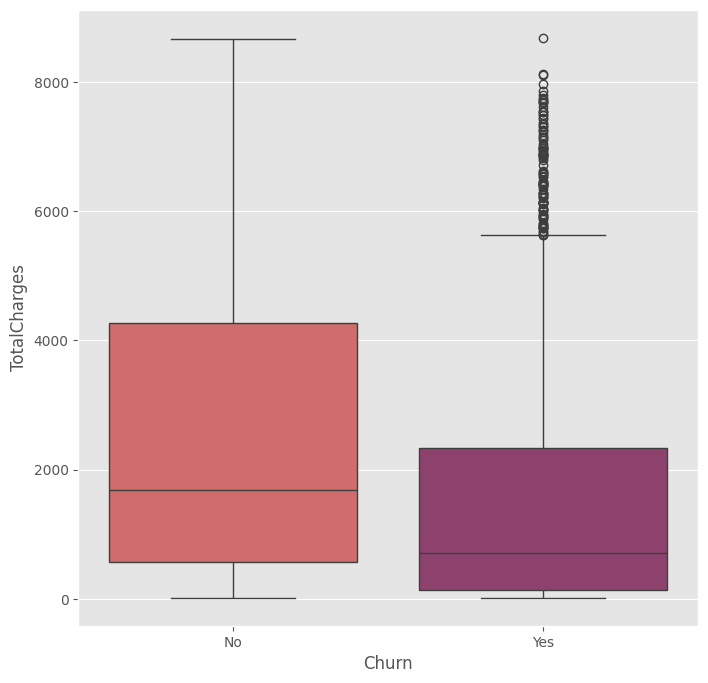

In [43]:
for col in num_cols:
    plt.figure(figsize=(8,8))
    sns.boxplot(y=df[col],x=df['Churn'],palette='flare')

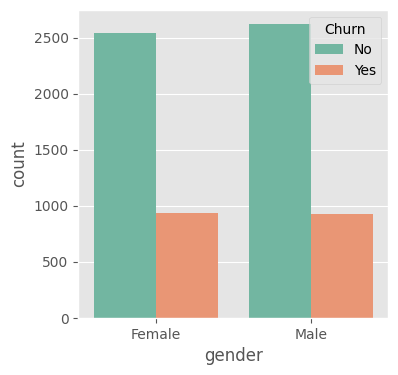

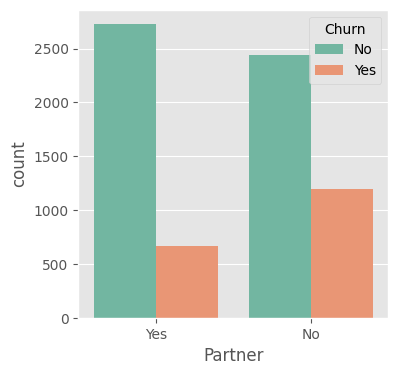

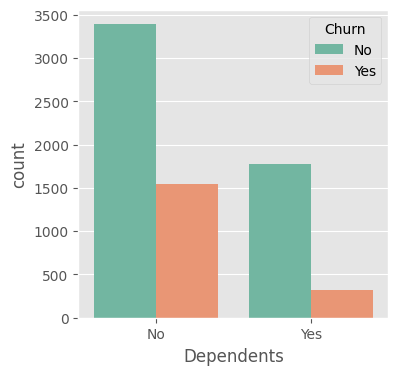

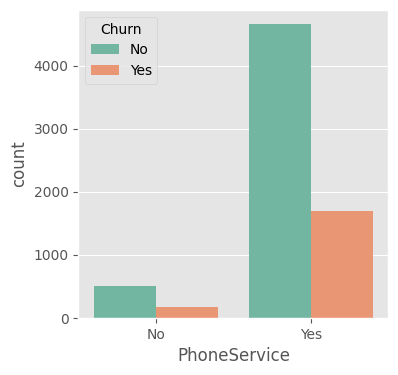

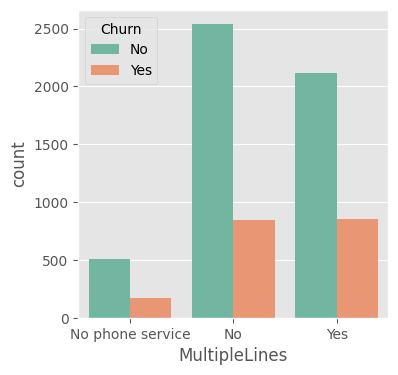

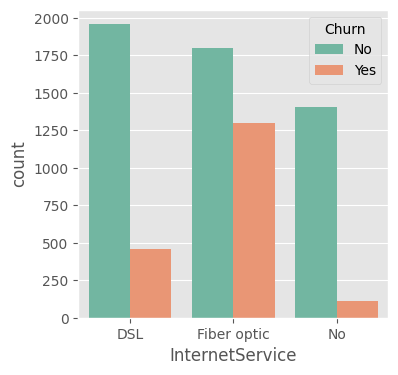

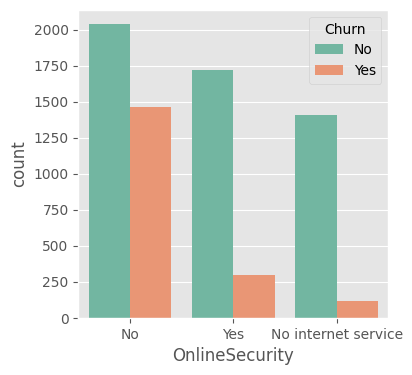

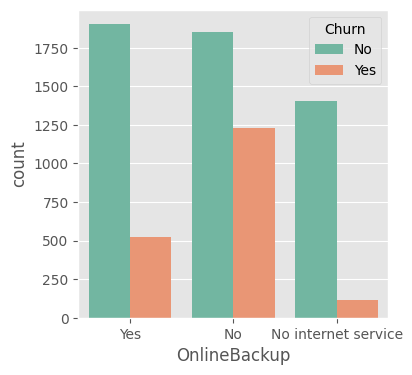

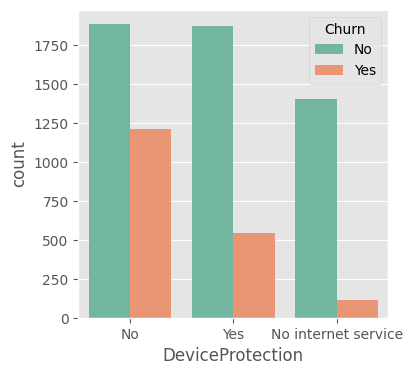

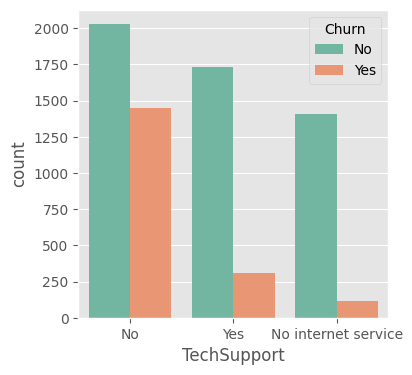

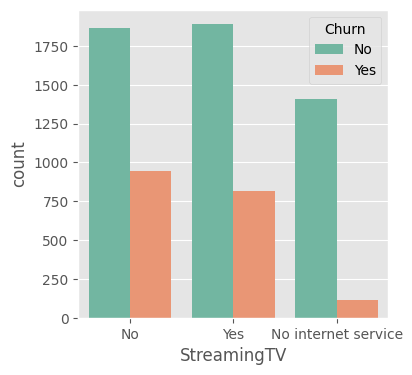

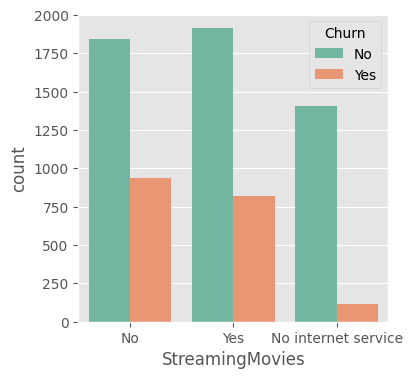

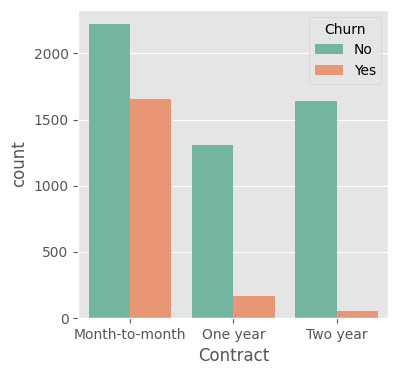

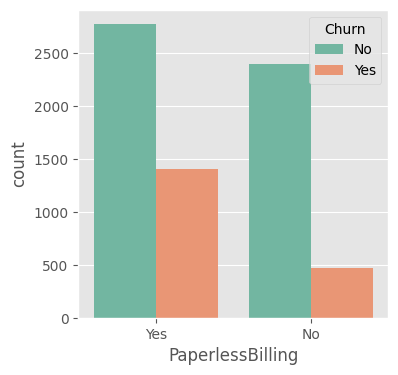

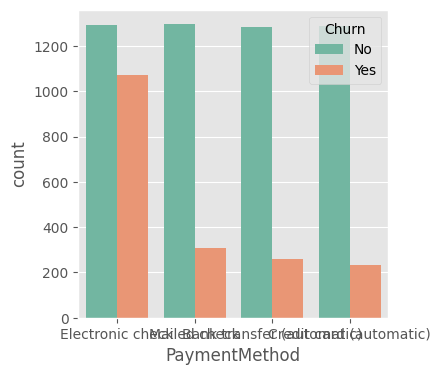

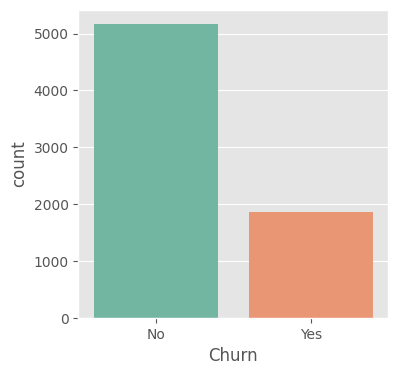

In [44]:
for col in cat_cols:
    plt.figure(figsize=(4,4))
    sns.countplot(x=df[col],hue=df['Churn'],palette='Set2')

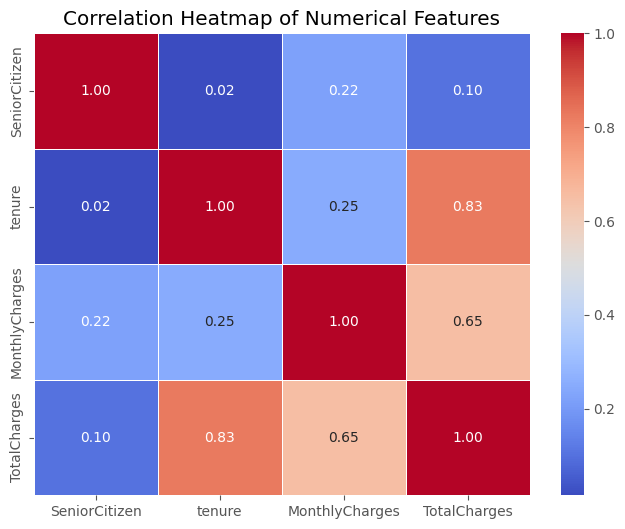

In [48]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

Feature Engineering 

In [71]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [72]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [75]:
num_features=X.select_dtypes(include=['int64','float64']).columns
cat_features=X.select_dtypes(include=['object']).columns
print("numerical  features are--",num_features)
print('categorical features are--',cat_features)

numerical  features are-- Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
categorical features are-- Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline

In [77]:
preprocessor=ColumnTransformer(transformers=[('num',StandardScaler(),num_features),
                                            ('cat',OneHotEncoder(handle_unknown='ignore'),cat_features)])

In [78]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
pipeline=Pipeline(steps=[('preprocessor',preprocessor),
                         ('model',LogisticRegression())
])

In [81]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [82]:
y_pred=pipeline.predict(X_test)

In [83]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [84]:
y_test

2481    0
6784    0
6125    1
3052    0
4099    0
       ..
1733    0
5250    0
5465    0
5851    0
3984    0
Name: Churn, Length: 1407, dtype: int64

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [89]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.7875
Precision: 0.6206
Recall   : 0.5160
F1 Score : 0.5635
ROC AUC  : 0.7009


In [69]:
accuracy

0.7874911158493249

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,
AdaBoostClassifier,ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [91]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [118]:
results=[]

In [119]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_pred)
    })

In [120]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
7,SVM,0.7903,0.6447,0.4706,0.5440,0.6883
3,Gradient Boosting,0.7889,0.6296,0.5000,0.5574,0.6968
0,Logistic Regression,0.7875,0.6206,0.5160,0.5635,0.7009
4,AdaBoost,0.7875,0.6263,0.4973,0.5544,0.6949
2,Random Forest,0.7775,0.6070,0.4626,0.5250,0.6771
5,Extra Trees,0.7733,0.5920,0.4733,0.5260,0.6776
6,KNN,0.7541,0.5393,0.5134,0.5260,0.6773
1,Decision Tree,0.7228,0.4792,0.4920,0.4855,0.6492
8,Naive Bayes,0.6837,0.4494,0.8422,0.5860,0.7343


In [121]:
from sklearn.model_selection import cross_val_score

In [122]:
cv_results=[]

In [123]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="accuracy",
    )

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

In [124]:
cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.round(4)
cv_df.sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

,Model,CV Mean Accuracy,CV Std
3,Gradient Boosting,0.8038,0.0125
0,Logistic Regression,0.8035,0.0067
4,AdaBoost,0.8026,0.0079
7,SVM,0.8008,0.0092
2,Random Forest,0.7888,0.0089
5,Extra Trees,0.7710,0.0129
6,KNN,0.7671,0.0067
1,Decision Tree,0.7263,0.0058
8,Naive Bayes,0.6940,0.0098


In [125]:
from sklearn.model_selection import GridSearchCV

In [126]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [127]:
param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5]
}

In [128]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [129]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Score: 0.8508980702422118


In [130]:
best_model = grid_search.best_estimator_

In [131]:
y_pred = best_model.predict(X_test)

In [133]:
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("ROC AUC  :", roc_auc_score(y_test,y_pred))

Accuracy : 0.7917555081734187
Precision: 0.6472727272727272
Recall   : 0.47593582887700536
F1 Score : 0.5485362095531587
ROC AUC  : 0.6910172852032656


In [134]:
import joblib

joblib.dump(best_model, "customer_churn_pipeline.pkl")

['customer_churn_pipeline.pkl']